In [1]:
import numpy as np
import pandas as pd

데이터 가지고 오기

In [2]:
retail_df=pd.read_excel('../data02/Online Retail.xlsx')
retail_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


데이터 정보 확인

In [3]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


null 확인

In [4]:
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

아이디에 null이 너무 많다. 아이디가 없으면 고객분석이 안돼.
이런거는 제거해야해.
0보다 작은게 있나 보니 -값이 있나봄.
값도 -인게 있네.

In [5]:
print((retail_df['Quantity']<0).sum())

10624


In [6]:
print((retail_df['UnitPrice']<0).sum())

2


In [7]:
print(retail_df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


일단 0부다 큰 값만 고르자.
널도 날리자.
불필요한 데이터 제거!!

In [8]:
retail_df=retail_df[retail_df['Quantity']>0]
retail_df=retail_df[retail_df['UnitPrice']>0]
retail_df=retail_df[retail_df['CustomerID'].notnull()]

In [9]:
print((retail_df['Quantity']<0).sum())
print((retail_df['UnitPrice']<0).sum())
print(retail_df.isnull().sum())

0
0
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


50만 데이터가 39만 데이터로 낮아짐.

In [10]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


중복데이터도 정리하자.

In [11]:
retail_df.drop_duplicates(inplace=True)
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


상품코드 종류

In [12]:
retail_df.StockCode.value_counts()

StockCode
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
          ... 
90214T       1
47016        1
90181A       1
84550        1
23843        1
Name: count, Length: 3665, dtype: int64

가장활발한 거래 20개를 뽑을 수 있어.

In [13]:
retail_df.StockCode.value_counts().head(20)

StockCode
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
20725     1304
22720     1152
POST      1099
23203     1091
20727     1078
22383     1063
22197     1060
21212     1050
23298     1021
23209     1020
22086     1003
22382      993
22469      979
20728      977
22457      972
Name: count, dtype: int64

id도 확인해보자.

In [14]:
retail_df.CustomerID.value_counts()

CustomerID
17841.0    7676
14911.0    5670
14096.0    5111
12748.0    4412
14606.0    2677
           ... 
15070.0       1
17102.0       1
17763.0       1
16078.0       1
13017.0       1
Name: count, Length: 4338, dtype: int64

어떤 나라에서 많이 구매를 하는가?

In [15]:
retail_df.Country.value_counts()

Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


정리가 완료된 현재데이터

In [16]:
retail_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


상품 수량도, 유닛가격도 나오는데 구매금액이 안나와. 구매금액 컬럼 만들자.

retail_df['SaleAmount'] 없는 필드라서 . 이 아니야.
구매금액 컬럼이 만들어짐.

In [17]:
retail_df['SaleAmount']=retail_df['Quantity']*retail_df['UnitPrice']
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SaleAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


ID가 실수인데 데이터 형을 정수로 만들자.

In [18]:
retail_df['CustomerID'] = retail_df['CustomerID'].astype('int')
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   SaleAmount   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB


고객을 그룹화하기 위해서
마케팅에 이용하기 위한 고객 주문수, 총구매금액, 마지막 주문 후 경과일

많이 구매하면 우수고객, 최근 주문 안한사람은 우수고객으로 두지 않게-
원하는 행으로 만들게 Groupby할거야

In [19]:
#Groupby를 위한 함수정의 
aggregation={
  'InvoiceNo':'count', 
  'SaleAmount':'sum',
  'InvoiceDate':'max' #맨마지막 주문일
}

customer_df = retail_df.groupby('CustomerID').agg(aggregation)
customer_df

,InvoiceNo,SaleAmount,InvoiceDate
CustomerID,,,
12346,1,77183.60,2011-01-18 10:01:00
12347,182,4310.00,2011-12-07 15:52:00
12348,31,1797.24,2011-09-25 13:13:00
12349,73,1757.55,2011-11-21 09:51:00
12350,17,334.40,2011-02-02 16:01:00
...,...,...,...
18280,10,180.60,2011-03-07 09:52:00
18281,7,80.82,2011-06-12 10:53:00
18282,12,178.05,2011-12-02 11:43:00


필드 이름을 바꾸자
전부 고칠때는 rename

In [20]:
customer_df=customer_df.rename(columns={
  'InvoiceNo':'Frequency',
  'InvoiceDate':'EpaspsedDays'
})
customer_df.head()

,Frequency,SaleAmount,EpaspsedDays
CustomerID,,,
12346,1,77183.60,2011-01-18 10:01:00
12347,182,4310.00,2011-12-07 15:52:00
12348,31,1797.24,2011-09-25 13:13:00
12349,73,1757.55,2011-11-21 09:51:00
12350,17,334.40,2011-02-02 16:01:00


현재 날짜로부터 몇일 지났다는 계산이 필요
맨 마지막 구매일로부터 지금까지

In [21]:
import datetime
customer_df['EpaspsedDays']=(datetime.datetime(2011, 12, 31)-customer_df['EpaspsedDays']) #구입하고 난 경과일 기준일 - 구매막날
customer_df['EpaspsedDays']=customer_df['EpaspsedDays'].apply(lambda x:x.days+1) #x:하면 EpaspsedDays 데이터 하나가 입력값
customer_df.head()

,Frequency,SaleAmount,EpaspsedDays
CustomerID,,,
12346,1,77183.60,347
12347,182,4310.00,24
12348,31,1797.24,97
12349,73,1757.55,40
12350,17,334.40,332


데이터가 어디에 몰려있는지 확인

In [22]:
import matplotlib.pyplot as plt
import os
import seaborn as sns
os.environ['KMP_DUPLICATE_LIB_OK']='True'

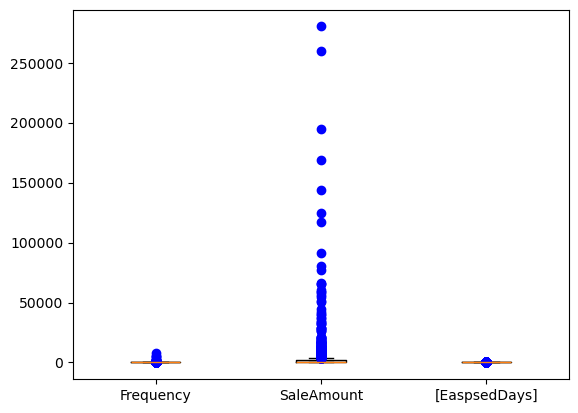

In [25]:
fig, ax=plt.subplots()
ax.boxplot([customer_df['Frequency'], customer_df['SaleAmount'], customer_df['EpaspsedDays']], sym='bo')

plt.xticks([1,2,3],['Frequency', 'SaleAmount','[EaspsedDays]'])
plt.show()

로그를 취해서 데이터의 스케일을 줄임.
0일때 값이 무한대 안만들려고 1p를 붙혀줘.
로그 1이 0에 제일 가까운 값

값차이가 너무 많이나면 필수적으로 해야해!!!!!!!!!!!!!!!!!!!!!!
값을 스케일에 맞춰서 비슷하게 하는게 중요해

In [26]:
customer_df['Frequency_log']=np.log1p(customer_df['Frequency'])
customer_df['SaleAmount_log']=np.log1p(customer_df['SaleAmount'])
customer_df['EpaspsedDays_log']=np.log1p(customer_df['EpaspsedDays'])
customer_df

,Frequency,SaleAmount,EpaspsedDays,Frequency_log,SaleAmount_log,EpaspsedDays_log
CustomerID,,,,,,
12346,1,77183.60,347,0.693147,11.253955,5.852202
12347,182,4310.00,24,5.209486,8.368925,3.218876
12348,31,1797.24,97,3.465736,7.494564,4.584967
12349,73,1757.55,40,4.304065,7.472245,3.713572
12350,17,334.40,332,2.890372,5.815324,5.808142
...,...,...,...,...,...,...
18280,10,180.60,299,2.397895,5.201806,5.703782
18281,7,80.82,202,2.079442,4.404522,5.313206
18282,12,178.05,29,2.564949,5.187665,3.401197


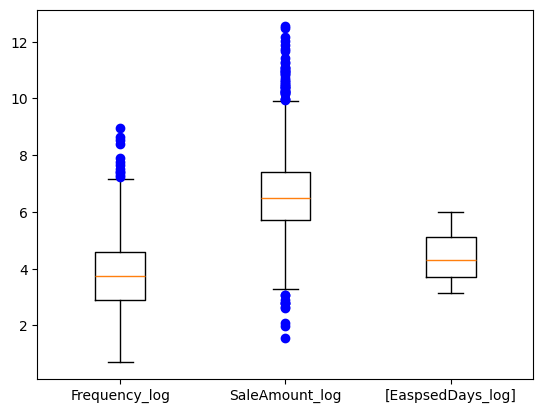

In [28]:
fig, ax=plt.subplots()
ax.boxplot([customer_df['Frequency_log'], customer_df['SaleAmount_log'], customer_df['EpaspsedDays_log']], sym='bo')

plt.xticks([1,2,3],['Frequency_log', 'SaleAmount_log','[EaspsedDays_log]'])
plt.show()

mean, max
스텐다드 스칼라 : 평균이 0 표준편차가 1이되게


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

전체데이터에서 3개의 필드값만 가지고 왔어.
x데이터

In [30]:
x_features=customer_df[['Frequency_log', 'SaleAmount_log', 'EpaspsedDays_log']].values
x_features

array([[ 0.69314718, 11.25395523,  5.85220248],
       [ 5.20948615,  8.36892517,  3.21887582],
       [ 3.4657359 ,  7.49456369,  4.58496748],
       ...,
       [ 2.56494936,  5.1876651 ,  3.40119738],
       [ 6.58202514,  7.62390095,  3.25809654],
       [ 4.26267988,  7.51658563,  4.17438727]])

로그 변환된 3개 변수들을
“평균 0, 표준편차 1” 기준으로 다시 바꿨다.

표준화 도구 (StandardScaler)

In [32]:
from sklearn.preprocessing import StandardScaler
x_features_scaled=StandardScaler().fit_transform(x_features)
x_features_scaled

array([[-2.43820181,  3.7077163 ,  1.75491769],
       [ 1.18898578,  1.41490344, -1.41929401],
       [-0.21146474,  0.72002428,  0.22739274],
       ...,
       [-0.9349095 , -1.11333158, -1.19952363],
       [ 2.29130702,  0.82281217, -1.37201737],
       [ 0.42858139,  0.73752572, -0.26752061]])

k 값을 엘보로 선택한다.
왜곡값 넣는 배열
for 문으로 왜곡값을 구한다.

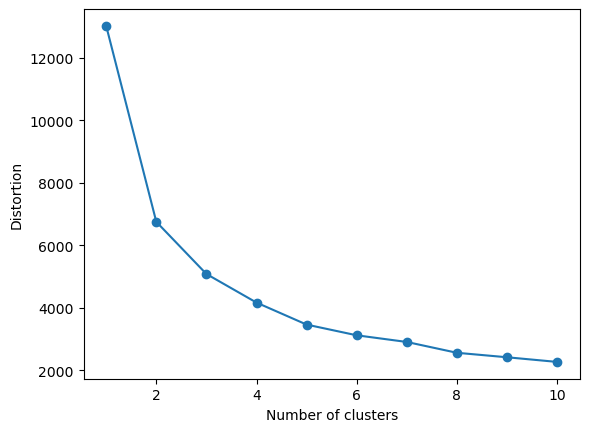

In [33]:
distortion=[]
for i in range(1, 11): #렌덤스테이트는 의미없고, 한가지값만 만들면 됨
  KMeans_i=KMeans(n_clusters=i, random_state=0) #KMean 객체 생성
  KMeans_i.fit(x_features_scaled) #Fit the model to the data (데이터 훈련)
  distortion.append(KMeans_i.inertia_) #군집 내의 거리 제곱

plt.plot(range(1, 11), distortion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()
 

엘보로 나눴을때 2로 나왔다.

훈련시킨다의 의미: 처음에는 임의의 값을 잡고 거리제곱을 하는데 중심점을 짧은 거리가 되도록 이동을 해.

살짝 꺾여있는 부분들이 좋은 클러스터
2번, 3번, 7번, 8번

우선 클러스터를 3개로 해서 훈련해본다.

In [42]:
kmean=KMeans(n_clusters=3, random_state=0)
y_labels=kmean.fit_predict(x_features_scaled) #훈련된 모델로 예측이 됨
y_labels

array([0, 1, 2, ..., 2, 1, 1], dtype=int32)

첫번째는 클러스트 0번, 두번째는 1번, 3번째는 2번..

In [43]:
customer_df['Cluster']=y_labels
customer_df

,Frequency,SaleAmount,EpaspsedDays,Frequency_log,SaleAmount_log,EpaspsedDays_log,Cluster
CustomerID,,,,,,,
12346,1,77183.60,347,0.693147,11.253955,5.852202,0
12347,182,4310.00,24,5.209486,8.368925,3.218876,1
12348,31,1797.24,97,3.465736,7.494564,4.584967,2
12349,73,1757.55,40,4.304065,7.472245,3.713572,1
12350,17,334.40,332,2.890372,5.815324,5.808142,0
...,...,...,...,...,...,...,...
18280,10,180.60,299,2.397895,5.201806,5.703782,0
18281,7,80.82,202,2.079442,4.404522,5.313206,0
18282,12,178.05,29,2.564949,5.187665,3.401197,2


각 데이터별 클러스터가 나와.
정답은 없어. 비지도학습이야.

In [36]:
kmean=KMeans(n_clusters=4, random_state=0)
y_labels=kmean.fit_predict(x_features_scaled) #훈련된 모델로 예측이 됨
y_labels

array([0, 1, 3, ..., 2, 1, 3], dtype=int32)

In [37]:
customer_df['Cluster']=y_labels
customer_df

,Frequency,SaleAmount,EpaspsedDays,Frequency_log,SaleAmount_log,EpaspsedDays_log,Cluster
CustomerID,,,,,,,
12346,1,77183.60,347,0.693147,11.253955,5.852202,0
12347,182,4310.00,24,5.209486,8.368925,3.218876,1
12348,31,1797.24,97,3.465736,7.494564,4.584967,3
12349,73,1757.55,40,4.304065,7.472245,3.713572,3
12350,17,334.40,332,2.890372,5.815324,5.808142,0
...,...,...,...,...,...,...,...
18280,10,180.60,299,2.397895,5.201806,5.703782,0
18281,7,80.82,202,2.079442,4.404522,5.313206,0
18282,12,178.05,29,2.564949,5.187665,3.401197,2


클러스터를 나눴어. 어떤 특성을 가지고 있는지 몰라.
어떤 특성을 가졌는지 보자.

그룹바이를 클러스터로.

In [44]:
group_customer=customer_df.groupby('Cluster').agg({
  'Frequency':'mean',
  'SaleAmount':'mean',
  'EpaspsedDays':'mean'
})
group_customer

,Frequency,SaleAmount,EpaspsedDays
Cluster,,,
0,20.931748,437.247101,239.519939
1,221.855234,5345.401330,52.443950
2,39.453468,661.993529,66.279787


0은 구매횟수 20번 평균, 금액 평균, 구매일 평균
1
2
3


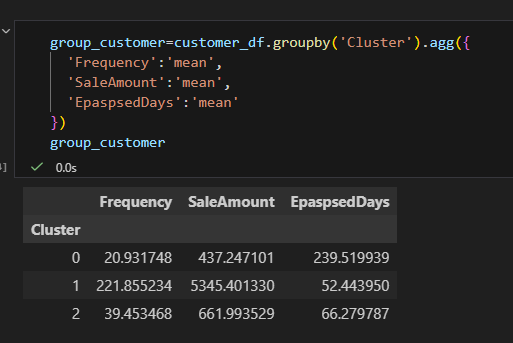

탈퇴구역이라면 혜택을 줄 수 있어.

특정상품 구매로 할수있어. 와아.. ㅇㅁㅇ.. 너무 종류가 많다.

자기들끼리 잘 모였는지 점수를 낼 수 있고, 그래프 가능

타켓을 세분화=클러스터 나누는게 타켓팅하기는 좋아.
군이 너무 작으면 포괄적이야.
실루엣스코어는 군을 적당하게 나누는데 도움.

In [52]:
from matplotlib import cm

In [53]:
def silhouetteViz(n_clusters, x_features): #()안에 것은 보낼 거, 
  kmean=KMeans(n_clusters=n_clusters, random_state=0) #KMean() 객체 생성
  y_labels=kmean.fit_predict(x_features) #모델예측

  silhouette_values=silhouette_samples(x_features, y_labels, metric='euclidean')
  print(silhouette_values)

  

In [62]:
def silhouetteViz(n_clusters, x_features): #()안에 것은 보낼 거, 
  kmean=KMeans(n_clusters=n_clusters, random_state=0) #KMean() 객체 생성
  y_labels=kmean.fit_predict(x_features) #모델예측

  silhouette_values=silhouette_samples(x_features, y_labels, metric='euclidean')
  # print(silhouette_values)
  y_ax_lower, y_ax_upper=0,0
  y_ticks=[]

  for i in range(n_clusters):
    cluster_silhouuttets=silhouette_values[y_labels==i] # 0, 1, 2 클러스터별 실루엣 값 얻기
    cluster_silhouuttets.sort() # 실루엣 값 정렬

    y_ax_upper+=len(cluster_silhouuttets) #0번 실루엣값이 100이면 1번 시작은 101 층층 그래프
    color=cm.jet(float(i)/n_clusters) #멧플롭립을 cm, (파란색, 오렌지.. cm에서 제공하는 칼라로 한다)

    plt.barh(range(y_ax_lower, y_ax_upper), cluster_silhouuttets, height=1.0, 
             edgecolor='none', color=color) #barh는 수평그래프

    y_ticks.append((y_ax_lower+y_ax_upper)/2) #눈금 1/2 지점에 그래프 붙히겠다.
    
    y_ax_lower+=len(cluster_silhouuttets)

  silhouette_avg=np.mean(silhouette_values)
  plt.axvline(silhouette_avg, color='red', linestyle='--') #전체 실루엣의 평균에 선을 긋겠다.

  plt.title(f'Silhoutte plot for n_clusters={n_clusters} Silhoutte score={silhouette_avg:4f}')
  plt.xlabel('Silhoutte Value')
  plt.ylabel('Cluster Label')
  plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
  plt.yticks(y_ticks, range(n_clusters))

  plt.show()

함수 호출

2도 넣어보고 3도 넣어보고

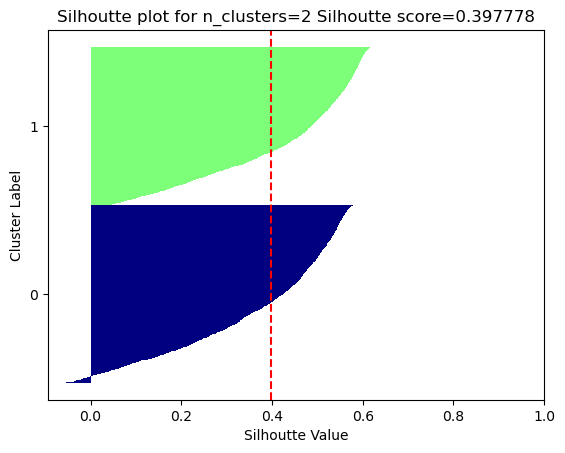

In [63]:
silhouetteViz(2, x_features_scaled)

왼쪽은 -값이 나와서 있는 부분이래.

실루엣 벨류가 나온다.
그래프를 그려보자. 작은거부터 큰수까지 정렬해서 그림그려

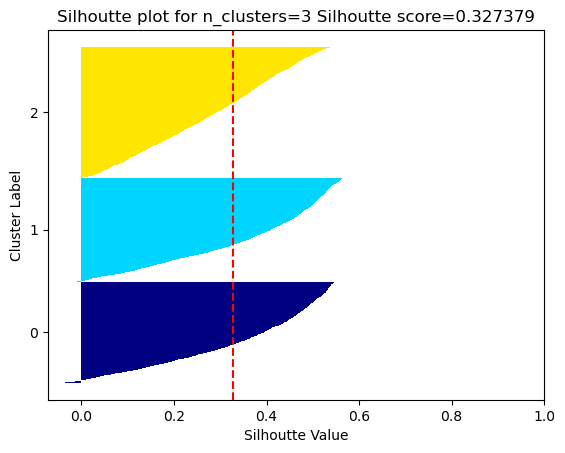

In [64]:
silhouetteViz(3, x_features_scaled)

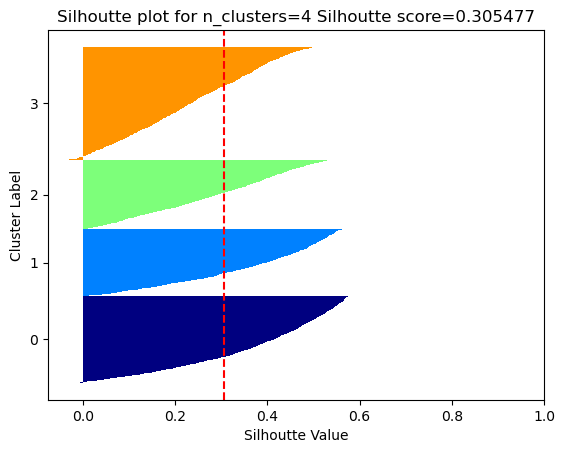

In [65]:
silhouetteViz(4, x_features_scaled)

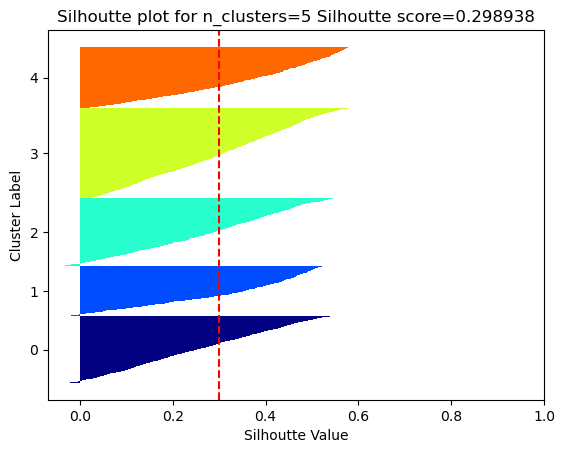

In [68]:
silhouetteViz(5, x_features_scaled)

4나 5나 값이 큰 차이가 없어. 그룹을 5개로 세분화해서 대응하는게 유리해.
클러스터를 높힐수록 제대로 분리가 안돼. 하지만 값이 미묘하게 차이가 나면 큰 것을 취사선택

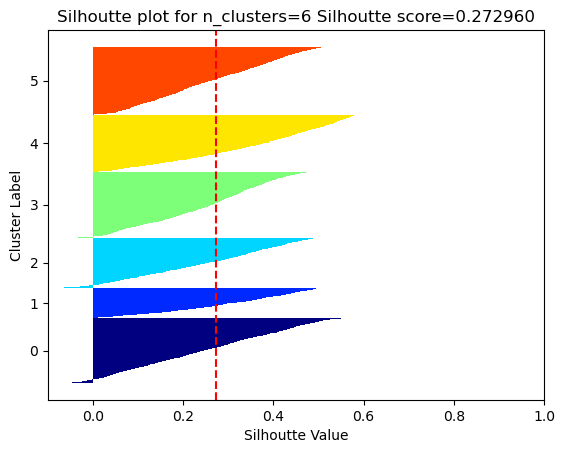

In [66]:
silhouetteViz(6, x_features_scaled)

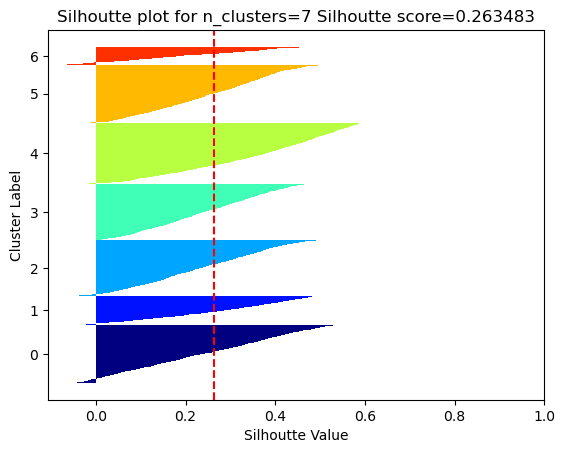

In [67]:
silhouetteViz(7, x_features_scaled)

클러스터의 데이터 분포를 스캐터 차트로 시각화

In [69]:
def clusterScatter(n_clusters, x_features):
  c_color=[]
  kmean=KMeans(n_clusters=n_clusters, random_state=0) #객체 만들기
  y_labels=kmean.fit_predict(x_features)

  for i in range(n_clusters): #n클러스터만큼 그린다.
    c_color.append(cm.jet(float(i)/n_clusters)) #컬러가 각각 나와
    print(c_color)

불러보자
컬러값이 들어가고 4개씩

1.0 불투명도
컬러값이 4개 만들어준다.

0.5 블루
0.5039 그린
0.4901
0.5816 컬러

In [70]:
clusterScatter(4, x_features_scaled)

[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0))]
[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0)), (np.float64(0.0), np.float64(0.503921568627451), np.float64(1.0), np.float64(1.0))]
[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0)), (np.float64(0.0), np.float64(0.503921568627451), np.float64(1.0), np.float64(1.0)), (np.float64(0.4901960784313725), np.float64(1.0), np.float64(0.4775458570524984), np.float64(1.0))]
[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0)), (np.float64(0.0), np.float64(0.503921568627451), np.float64(1.0), np.float64(1.0)), (np.float64(0.4901960784313725), np.float64(1.0), np.float64(0.4775458570524984), np.float64(1.0)), (np.float64(1.0), np.float64(0.5816993464052289), np.float64(0.0), np.float64(1.0))]


In [74]:
def clusterScatter(n_clusters, x_features):
  c_color=[]
  kmean=KMeans(n_clusters=n_clusters, random_state=0) #객체 만들기
  y_labels=kmean.fit_predict(x_features)

  for i in range(n_clusters): #n클러스터만큼 그린다.
    c_color.append(cm.jet(float(i)/n_clusters)) #컬러가 각각 나와
    print(c_color)
    plt.scatter(x_features[y_labels==i,0],  #점찍는 내용
                x_features[y_labels==i,1],
                c=c_color[i],
                edgecolors='black', label=f'Cluster {i}', s=50) #s는 크기
    
  for i in range(n_clusters):
    plt.scatter(kmean.cluster_centers_[i,0],#클러스터 i번째 0일때 중간위치, 1일때 중간위치?
                kmean.cluster_centers_[i,1],
                c=c_color[i], marker='^', s=200, edgecolors='w') 
    
  plt.legend()
  plt.title(f'KMean Clustering with n_cluster:{n_clusters}')
  plt.show()


[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0))]
[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0)), (np.float64(0.0), np.float64(0.503921568627451), np.float64(1.0), np.float64(1.0))]
[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0)), (np.float64(0.0), np.float64(0.503921568627451), np.float64(1.0), np.float64(1.0)), (np.float64(0.4901960784313725), np.float64(1.0), np.float64(0.4775458570524984), np.float64(1.0))]
[(np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0)), (np.float64(0.0), np.float64(0.503921568627451), np.float64(1.0), np.float64(1.0)), (np.float64(0.4901960784313725), np.float64(1.0), np.float64(0.4775458570524984), np.float64(1.0)), (np.float64(1.0), np.float64(0.5816993464052289), np.float64(0.0), np.float64(1.0))]


C:\Users\it\AppData\Local\Temp\ipykernel_9244\1249945600.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_features[y_labels==i,0],  #점찍는 내용
C:\Users\it\AppData\Local\Temp\ipykernel_9244\1249945600.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(kmean.cluster_centers_[i,0],#클러스터 i번째 0일때 중간위치, 1일때 중간위치?


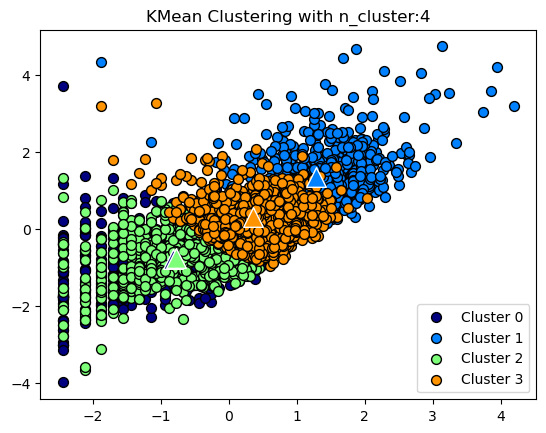

In [75]:
clusterScatter(4, x_features_scaled)

0번이랑 2번이 겹쳐져있어, 
1번 구매, 빈도 모두 높아
3번 평균고객군
3번 활동도, 가치 낮은 군 -> 휴면, 이탈 위험
0 2와 겹침 